<a href="https://colab.research.google.com/github/muhammadzohaib09001-dotcom/FACIAL_EMOTION_RECOGNATION_USING_CNN_TRANSFER_LEARNING/blob/main/FacialEmotionRecognition_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PAM2002 Data Science Project
##Facial Emotion Recognition Using CNN and Transfer Learning
##Student: Muhammad Zohaib Khan
##Module: 7PAM2002 Data Science Project
##Semester: A 2025/2026

---

## Research Questions
1. How do different data preprocessing and augmentation methods affect the performance of facial emotion recognition models?
2. How do different CNN architectures compare in extracting facial features for emotion recognition?
3. How does the performance of CNN-based models compare with that of Transfer models for facial emotion recognition from images?
4. How do CNN and Transfer models differ in classification performance and error patterns when evaluated using standard metrics?


## Table of Contents
1. [Environment Setup & Imports](#1)
2. [Dataset Loading](#2)
3. [Exploratory Data Analysis (EDA)](#3)
4. [Data Preprocessing & Class Imbalance Handling](#4)
5. [Data Augmentation & DataLoaders](#5)
6. [Model 1: Simple Custom CNN Model](#6)
7. [Model 2: Hypermodel CNN Fine Tunned](#7)



# 1. Importing Libraries



In [1]:
!pip install keras-tuner

In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import tensorflow as tf
import keras_tuner as kt
from tensorflow import keras
from tensorflow.keras import layers, models

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# 2. Dataset Loading

In [4]:
dataset_path = "/content/drive/MyDrive/emotion-recognition-dataset/Dataset/dataset/"

print("Dataset path exists:", os.path.exists(dataset_path))
print("Folders/classes:", os.listdir(dataset_path))

Dataset path exists: True
Folders/classes: ['Sad', 'Neutral', 'Surprise', 'Happy', 'Angry', 'Ahegao']


Setting Image and Batch Side

In [5]:
IMG_SIZE = (64, 64)
BATCH_SIZE = 32

Loading the dataset using Keras:

In [6]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.30,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.30,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

Found 15454 files belonging to 6 classes.
Using 10818 files for training.
Found 15454 files belonging to 6 classes.
Using 4636 files for validation.


Now spliting the temporary 30% into validation and test sets.

In [7]:
val_batches = tf.data.experimental.cardinality(temp_ds)
test_ds = temp_ds.take(val_batches // 2)
val_ds = temp_ds.skip(val_batches // 2)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Class names:", class_names)
print("Number of classes:", num_classes)

Class names: ['Ahegao', 'Angry', 'Happy', 'Neutral', 'Sad', 'Surprise']
Number of classes: 6


# 3. Exploratory Data Analysis

**Display Sample Images**

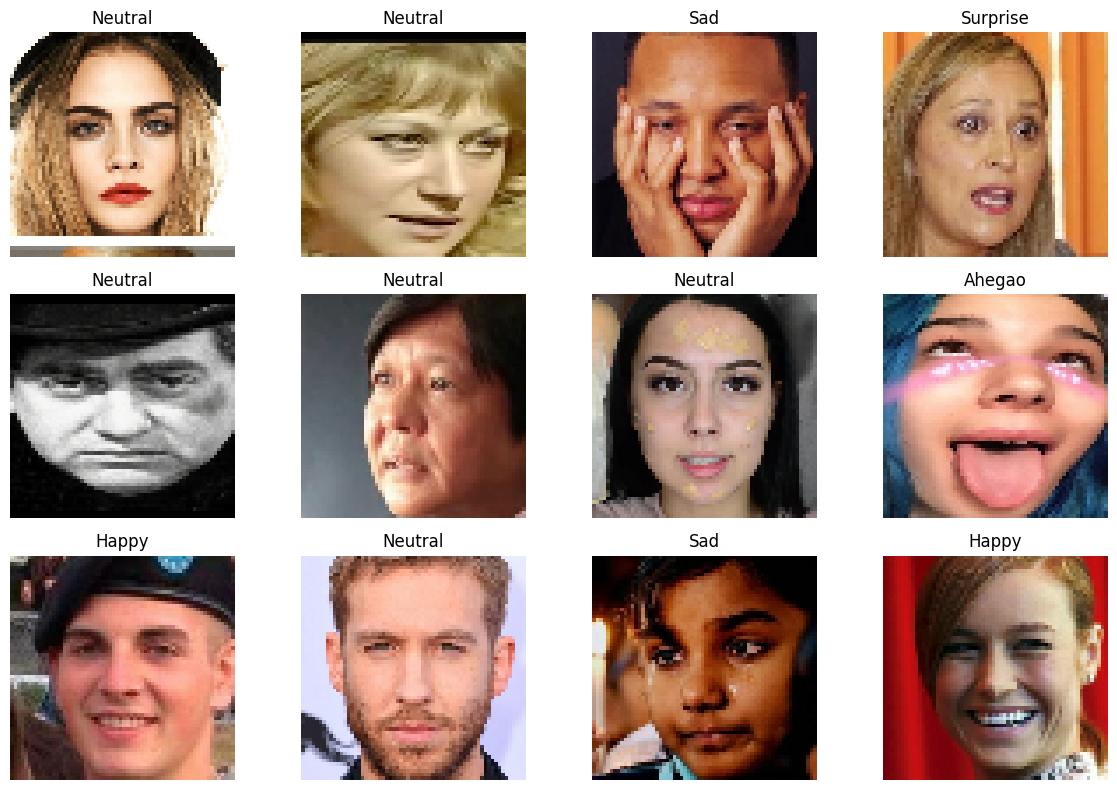

In [8]:
plt.figure(figsize=(12, 8))

for images, labels in train_ds.take(1):
    for i in range(min(12, len(images))):
        plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

**Class Distribution**

In [9]:
class_counts = {}

for class_name in class_names:
    class_dir = os.path.join(dataset_path, class_name)
    class_counts[class_name] = len([
        file for file in os.listdir(class_dir)
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
    ])

print("Class distribution:")
for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")

Class distribution:
Ahegao: 1206
Angry: 1313
Happy: 3740
Neutral: 4027
Sad: 3934
Surprise: 1234


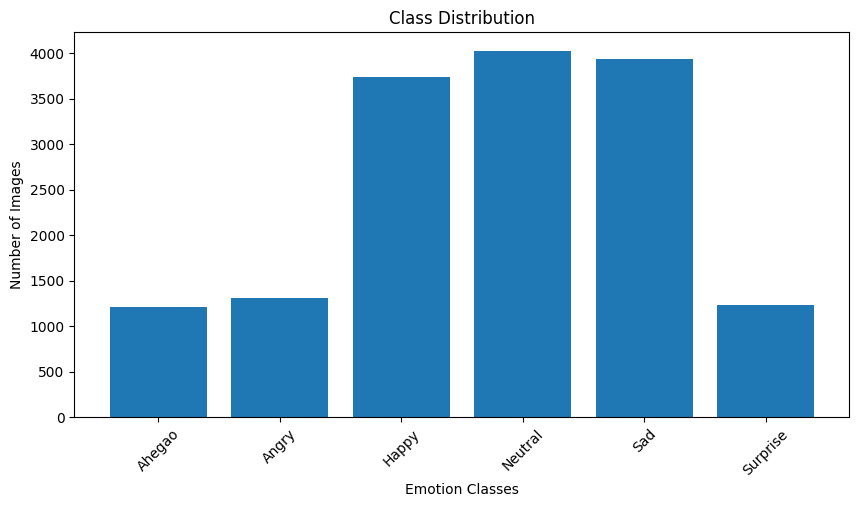

In [10]:
plt.figure(figsize=(10, 5))
plt.bar(class_counts.keys(), class_counts.values())
plt.xlabel("Emotion Classes")
plt.ylabel("Number of Images")
plt.title("Class Distribution")
plt.xticks(rotation=45)
plt.show()

# 4. Data Preprocessing & Class Imbalance Handling

Images loaded by image_dataset_from_directory are originally in the range 0 to 255. We will normalize them to 0 to 1 inside the model using a Rescaling layer.
 For imbalance handling, we will calculate class weights.

In [11]:
all_labels = []

for class_index, class_name in enumerate(class_names):
    class_dir = os.path.join(dataset_path, class_name)

    image_files = [
        file for file in os.listdir(class_dir)
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
    ]

    all_labels.extend([class_index] * len(image_files))

all_labels = np.array(all_labels)

class_weights_values = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(all_labels),
    y=all_labels
)

class_weights = {
    i: class_weights_values[i]
    for i in range(len(class_weights_values))
}

print("Class weights:")
print(class_weights)

Class weights:
{0: np.float64(2.1357103372028745), 1: np.float64(1.9616653973089617), 2: np.float64(0.6886809269162211), 3: np.float64(0.6395993709130039), 4: np.float64(0.6547195390611761), 5: np.float64(2.0872501350621286)}


These weights will be passed to model.fit() later:

In [12]:
class_weight=class_weights

# 5. Data Augmentation & DataLoaders

In [13]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1)
], name="data_augmentation")

**Improve Loading Performance**

In [14]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

# 6. Defining Simple Custom CNN Model

In [15]:
model = keras.Sequential([
    layers.Input(shape=(64, 64, 3)),

    layers.Rescaling(1./255),

    data_augmentation,

    layers.Conv2D(16, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation="softmax")
])

**Model Summery**

In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 548,774 (2.09 MB)

 Trainable params: 548,774 (2.09 MB)

 Non-trainable params: 0 (0.00 B)

**Compile the Model**

In [17]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Train the Simple CNN Model

In [18]:
EPOCHS = 35

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights
)

Epoch 1/35
339/339 ━━━━━━━━━━━━━━━━━━━━ 26s 23ms/step - accuracy: 0.2309 - loss: 1.7182 - val_accuracy: 0.2779 - val_loss: 1.6171
Epoch 2/35
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3015 - loss: 1.5777 - val_accuracy: 0.3036 - val_loss: 1.5691
Epoch 3/35
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3263 - loss: 1.5135 - val_accuracy: 0.3079 - val_loss: 1.6068
Epoch 4/35
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3417 - loss: 1.4672 - val_accuracy: 0.3581 - val_loss: 1.5766
Epoch 5/35
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3492 - loss: 1.4293 - val_accuracy: 0.3593 - val_loss: 1.4647
Epoch 6/35
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3605 - loss: 1.3983 - val_accuracy: 0.4039 - val_loss: 1.3945
Epoch 7/35
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3757 - loss: 1.3636 - val_accuracy: 0.3885 - val_loss: 1.4114
Epoch 8/35
339/339 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3847 - loss: 1.3442 - val_accuracy: 

**Plot Training and Validation Results**

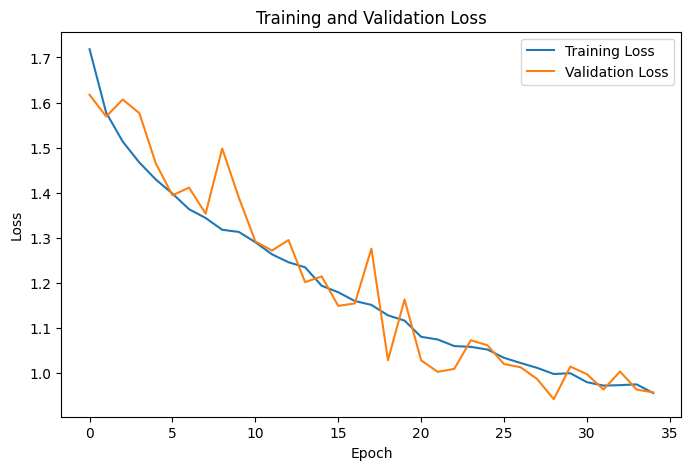

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

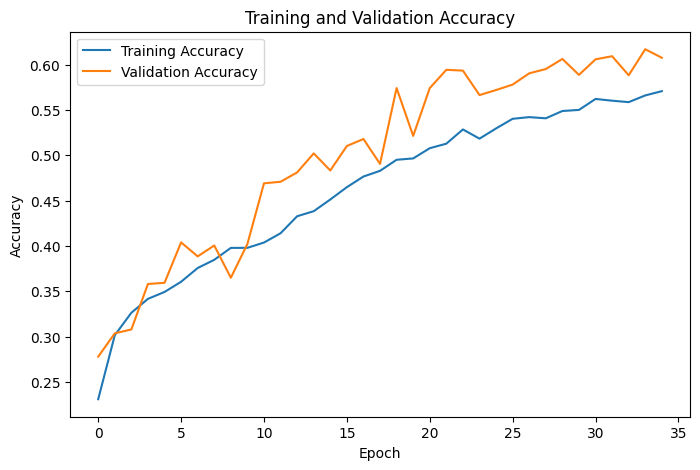

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

# Evaluate on Test Set

In [21]:
test_loss, test_accuracy = model.evaluate(test_ds)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.6128 - loss: 0.9704
Test Loss: 0.9704
Test Accuracy: 0.6128


**Classification Report and Confusion Matrix**

In [22]:
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [23]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

      Ahegao       0.67      0.95      0.79       172
       Angry       0.35      0.72      0.47       190
       Happy       0.83      0.73      0.77       502
     Neutral       0.56      0.69      0.62       612
         Sad       0.68      0.34      0.45       623
    Surprise       0.66      0.54      0.59       205

    accuracy                           0.61      2304
   macro avg       0.63      0.66      0.62      2304
weighted avg       0.65      0.61      0.61      2304



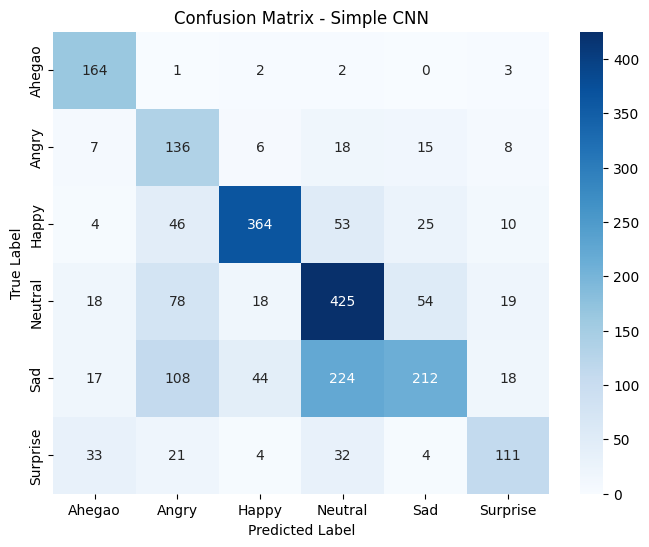

In [24]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names,
    cmap="Blues"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Simple CNN")
plt.show()

# Showing Sample Predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


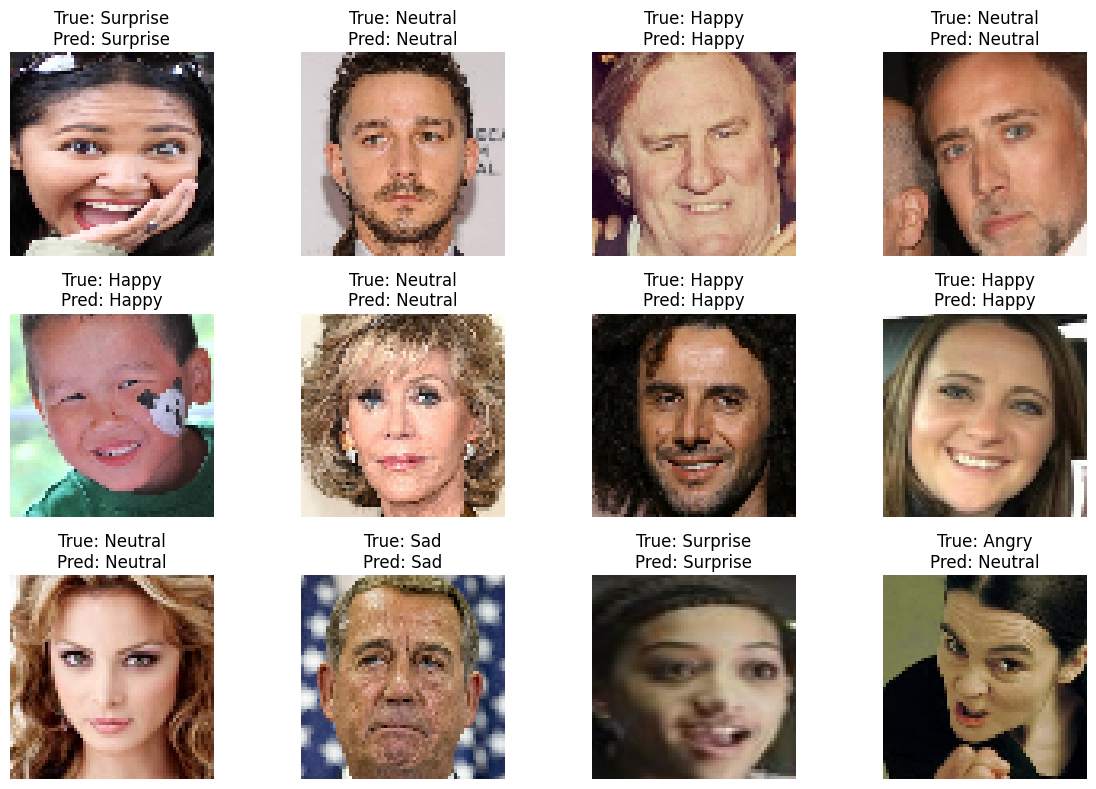

In [25]:
plt.figure(figsize=(12, 8))

for images, labels in test_ds.take(1):
    predictions = model.predict(images)
    predicted_classes = np.argmax(predictions, axis=1)

    for i in range(min(12, len(images))):
        plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))

        true_label = class_names[labels[i]]
        predicted_label = class_names[predicted_classes[i]]

        plt.title(f"True: {true_label}\nPred: {predicted_label}")
        plt.axis("off")

plt.tight_layout()
plt.show()

In [26]:
model.save("/content/drive/MyDrive/simple_cnn_emotion_model.keras")

# 7. Defining the Hypermodel
(mean model with hyper parameter tunning)

In [27]:
def build_safe_tuned_cnn(hp):
    model = keras.Sequential([
        layers.Input(shape=(64, 64, 3)),

        # Normalize pixel values
        layers.Rescaling(1./255),

        # Data augmentation
        data_augmentation,

        # Conv Block 1
        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # Conv Block 2
        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # Conv Block 3
        layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # Extra Conv Block 4
        layers.Conv2D(256, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),

        layers.Dense(
            units=hp.Choice("dense_units", values=[64, 128, 256, 512]),
            activation="relu"
        ),
        layers.BatchNormalization(),

        layers.Dropout(
            rate=hp.Choice("dropout_rate", values=[0.2, 0.3, 0.4, 0.5])
        ),

        layers.Dense(num_classes, activation="softmax")
    ])

    learning_rate = hp.Choice(
        "learning_rate",
        values=[1e-3, 5e-4, 1e-4]
    )

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

# Create the Tuner

We will use Random Search.
Random Search tests random combinations of hyperparameters. It is simple and effective for a second baseline model.

In [28]:
tuner_safe = kt.RandomSearch(
    hypermodel=build_safe_tuned_cnn,
    objective="val_accuracy",
    max_trials=20,
    executions_per_trial=1,
    directory="/content/tuning_results",
    project_name="safe_tuned_cnn_bn",
    overwrite=True
)

**View Search Space**

In [29]:
tuner_safe.search_space_summary()

Search space summary
Default search space size: 3
dense_units (Choice)
{'default': 64, 'conditions': [], 'values': [64, 128, 256, 512], 'ordered': True}
dropout_rate (Choice)
{'default': 0.2, 'conditions': [], 'values': [0.2, 0.3, 0.4, 0.5], 'ordered': True}
learning_rate (Choice)
{'default': 0.001, 'conditions': [], 'values': [0.001, 0.0005, 0.0001], 'ordered': True}


# Run Hyperparameter Tuning

In [30]:
early_stopping_safe = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [31]:
tuner_safe.search(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stopping_safe]
)
# This will train multiple CNN models and select the best one.

Trial 20 Complete [00h 00m 57s]
val_accuracy: 0.5994853973388672

Best val_accuracy So Far: 0.6848198771476746
Total elapsed time: 00h 18m 02s


# Show Best Hyperparameters

In [32]:
best_hps_safe = tuner_safe.get_best_hyperparameters(num_trials=1)[0]

print("Best Hyperparameters:")
print("Dense Units:", best_hps_safe.get("dense_units"))
print("Dropout Rate:", best_hps_safe.get("dropout_rate"))
print("Learning Rate:", best_hps_safe.get("learning_rate"))

Best Hyperparameters:
Dense Units: 128
Dropout Rate: 0.2
Learning Rate: 0.0005


# Build the Best Model

In [33]:
best_safe_tuned_model = tuner_safe.hypermodel.build(best_hps_safe)

best_safe_tuned_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 916,038 (3.49 MB)

 Trainable params: 914,822 (3.49 MB)

 Non-trainable params: 1,216 (4.75 KB)

# Train the Best Tuned CNN Model Fully

After finding the best hyperparameters, train the best model again for more epochs.

In [34]:
early_stopping_final_safe = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_safe_tuned = best_safe_tuned_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    class_weight=class_weights,
    callbacks=[early_stopping_final_safe]
)

Epoch 1/30
339/339 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.2800 - loss: 1.7601 - val_accuracy: 0.2877 - val_loss: 1.6305
Epoch 2/30
339/339 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.3377 - loss: 1.5241 - val_accuracy: 0.3641 - val_loss: 1.4910
Epoch 3/30
339/339 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.4015 - loss: 1.3771 - val_accuracy: 0.3726 - val_loss: 1.5156
Epoch 4/30
339/339 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.4517 - loss: 1.2667 - val_accuracy: 0.2920 - val_loss: 2.0254
Epoch 5/30
339/339 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.4958 - loss: 1.1780 - val_accuracy: 0.4841 - val_loss: 1.2744
Epoch 6/30
339/339 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.5315 - loss: 1.0901 - val_accuracy: 0.5690 - val_loss: 1.0818
Epoch 7/30
339/339 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.5691 - loss: 0.9945 - val_accuracy: 0.5523 - val_loss: 1.0935
Epoch 8/30
339/339 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.5833 - loss: 0.9444 - val_accu

**Ploting Tuned Model Accuracy and Loss**

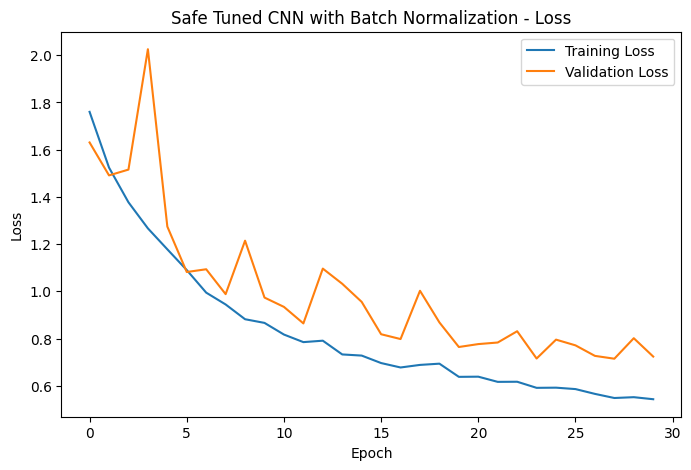

In [35]:
plt.figure(figsize=(8, 5))
plt.plot(history_safe_tuned.history["loss"], label="Training Loss")
plt.plot(history_safe_tuned.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Safe Tuned CNN with Batch Normalization - Loss")
plt.legend()
plt.show()

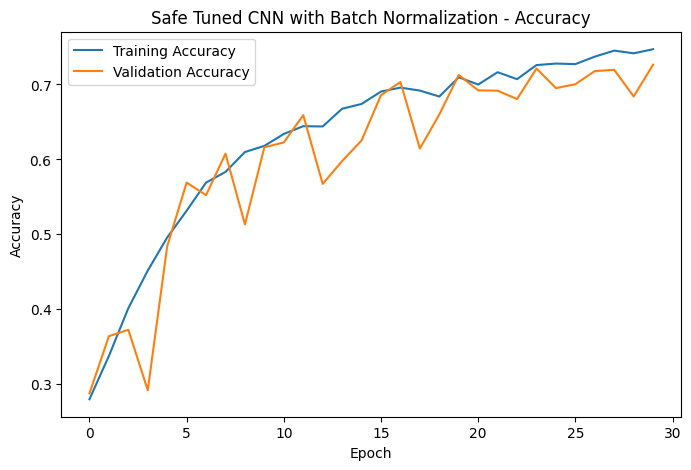

In [36]:
plt.figure(figsize=(8, 5))
plt.plot(history_safe_tuned.history["accuracy"], label="Training Accuracy")
plt.plot(history_safe_tuned.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Safe Tuned CNN with Batch Normalization - Accuracy")
plt.legend()
plt.show()

# Evaluate Tuned CNN on Test Set

In [37]:
test_loss_safe, test_accuracy_safe = best_safe_tuned_model.evaluate(test_ds)

print(f"Safe Tuned CNN Test Loss: {test_loss_safe:.4f}")
print(f"Safe Tuned CNN Test Accuracy: {test_accuracy_safe:.4f}")

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7227 - loss: 0.6941
Safe Tuned CNN Test Loss: 0.6941
Safe Tuned CNN Test Accuracy: 0.7227


# Classification Report for Tuned CNN

In [38]:
y_true_safe = []
y_pred_safe = []

for images, labels in test_ds:
    predictions = best_safe_tuned_model.predict(images, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)

    y_true_safe.extend(labels.numpy())
    y_pred_safe.extend(predicted_classes)

y_true_safe = np.array(y_true_safe)
y_pred_safe = np.array(y_pred_safe)

In [39]:
print(classification_report(
    y_true_safe,
    y_pred_safe,
    target_names=class_names
))

              precision    recall  f1-score   support

      Ahegao       0.96      0.90      0.93       172
       Angry       0.54      0.69      0.61       190
       Happy       0.86      0.87      0.86       502
     Neutral       0.72      0.58      0.64       612
         Sad       0.67      0.69      0.68       623
    Surprise       0.62      0.75      0.68       205

    accuracy                           0.72      2304
   macro avg       0.73      0.75      0.73      2304
weighted avg       0.73      0.72      0.72      2304



# Confusion Matrix for Tuned CNN

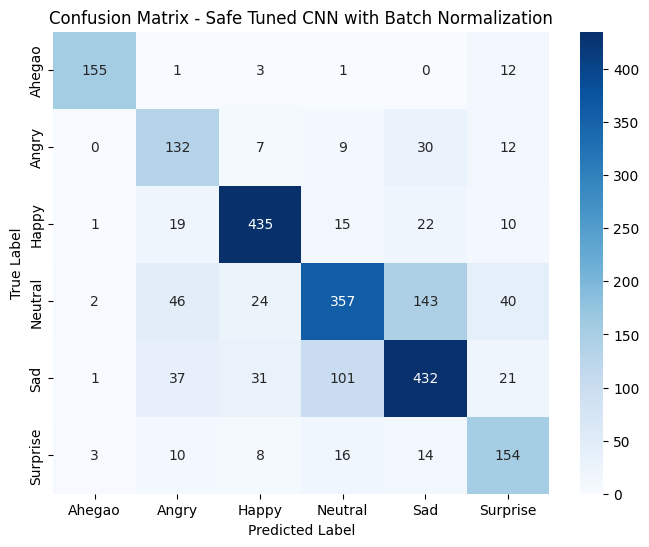

In [40]:
cm_safe = confusion_matrix(y_true_safe, y_pred_safe)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_safe,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names,
    cmap="Blues"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Safe Tuned CNN with Batch Normalization")
plt.show()

# Compare Simple CNN vs Tuned CNN

In [41]:
print("Simple CNN Test Accuracy:", test_accuracy)
print("Safe Tuned CNN Test Accuracy:", test_accuracy_safe)

Simple CNN Test Accuracy: 0.6128472089767456
Safe Tuned CNN Test Accuracy: 0.72265625


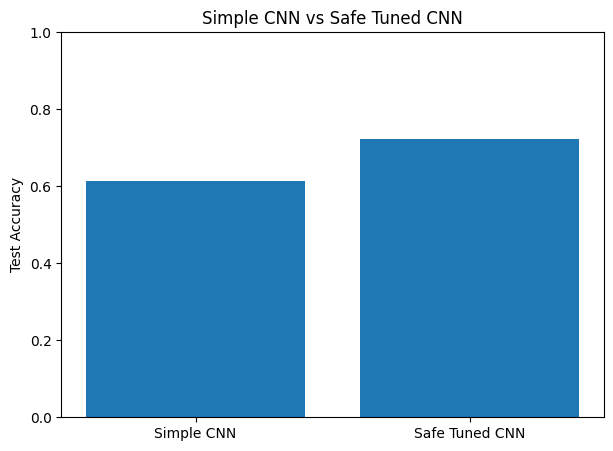

In [42]:
model_names = ["Simple CNN", "Safe Tuned CNN"]
model_accuracies = [test_accuracy, test_accuracy_safe]

plt.figure(figsize=(7, 5))
plt.bar(model_names, model_accuracies)
plt.ylabel("Test Accuracy")
plt.title("Simple CNN vs Safe Tuned CNN")
plt.ylim(0, 1)
plt.show()

# Save the Tuned CNN Model

In [43]:
best_safe_tuned_model.save("/content/drive/MyDrive/safe_tuned_cnn_bn_model.keras")